In [33]:
import numpy as np
from matplotlib import pyplot as plt

rng = np.random.default_rng()

In [34]:
N0 = 25000
dt = 1.0
max_steps = 50000

# half lives
t_half_Rn = 3.02 * 24 * 60
t_half_Po = 31.0
t_half_Pb = 26.8
t_half_Bi = 19.9
t_half_Tl = 13.0

p_Rn = 1.0 - 2.0**(-dt / t_half_Rn)
p_Po = 1.0 - 2.0**(-dt / t_half_Po)
p_Pb = 1.0 - 2.0**(-dt / t_half_Pb)
p_Bi = 1.0 - 2.0**(-dt / t_half_Bi)
p_Tl = 1.0 - 2.0**(-dt / t_half_Tl)

#probabss percentages
Po_to_Pb_prob = 0.98
Po_to_Bi_prob = 0.02

Bi_to_Pb_prob = 0.87
Bi_to_Tl_prob = 0.13

E_alpha = 5.0
E_R = 2.0
E_beta = 0.5
E_Z = 12.0

In [35]:
def simulate_one_run():

    # current numbers of each isotope
    N_Rn    = N0
    N_Po    = 0
    N_Pb    = 0    # 214Pb
    N_Bi    = 0    # 214Bi
    N_Tl    = 0    # 207Tl
    N_Pb207 = 0    # final stable 207Pb

    # lists for plotting
    t_list     = []
    Rn_list    = []
    Po_list    = []
    Pb214_list = []
    Bi214_list = []
    Tl207_list = []
    Pb207_list = []

    # track energy and counts per decay type
    energy_by_type = {"a": 0.0, "b": 0.0, "R": 0.0, "Z": 0.0}
    counts_by_type = {"a": 0,   "b": 0,   "R": 0,   "Z": 0}

    t = 0.0

    for step in range(max_steps):
        # record current state for plotting
        t_list.append(t)
        Rn_list.append(N_Rn)
        Po_list.append(N_Po)
        Pb214_list.append(N_Pb)
        Bi214_list.append(N_Bi)
        Tl207_list.append(N_Tl)
        Pb207_list.append(N_Pb207)

        # if all in 207Pb we goood
        if (N_Rn + N_Po + N_Pb + N_Bi + N_Tl) == 0:
            break

        # 1) 207Tl to 207Pb
        if N_Tl > 0:
            dec_Tl = rng.binomial(N_Tl, p_Tl)
            if dec_Tl > 0:
                N_Tl    -= dec_Tl
                N_Pb207 += dec_Tl

                counts_by_type["b"] += dec_Tl
                energy_by_type["b"] += dec_Tl * E_beta

        # 2) 214Bi to 207Pb
        if N_Bi > 0:
            dec_Bi = rng.binomial(N_Bi, p_Bi)
            if dec_Bi > 0:
                to_Pb207_beta = rng.binomial(dec_Bi, Bi_to_Pb_prob)
                to_Tl = dec_Bi - to_Pb207_beta

                N_Bi    -= dec_Bi
                N_Pb207 += to_Pb207_beta
                N_Tl    += to_Tl

                # beta branch
                counts_by_type["b"] += to_Pb207_beta
                energy_by_type["b"] += to_Pb207_beta * E_beta

                # alpha branch
                counts_by_type["a"] += to_Tl
                energy_by_type["a"] += to_Tl * E_alpha

        # 3) 214Pb to 214Bi
        if N_Pb > 0:
            dec_Pb = rng.binomial(N_Pb, p_Pb)
            if dec_Pb > 0:
                N_Pb -= dec_Pb
                N_Bi += dec_Pb

                counts_by_type["Z"] += dec_Pb
                energy_by_type["Z"] += dec_Pb * E_Z

        # 4) 218Po to 214Pb
        if N_Po > 0:
            dec_Po = rng.binomial(N_Po, p_Po)
            if dec_Po > 0:
                to_Pb = rng.binomial(dec_Po, Po_to_Pb_prob)
                to_Bi = dec_Po - to_Pb

                N_Po -= dec_Po
                N_Pb += to_Pb
                N_Bi += to_Bi

                # alpha branch
                counts_by_type["a"] += to_Pb
                energy_by_type["a"] += to_Pb * E_alpha

                # R branch
                counts_by_type["R"] += to_Bi
                energy_by_type["R"] += to_Bi * E_R

        # 5) 222Rn to 218Po
        if N_Rn > 0:
            dec_Rn = rng.binomial(N_Rn, p_Rn)
            if dec_Rn > 0:
                N_Rn -= dec_Rn
                N_Po += dec_Rn

                counts_by_type["R"] += dec_Rn
                energy_by_type["R"] += dec_Rn * E_R

        t += dt

    # convert to arays
    time_array = np.array(t_list)
    Rn_array   = np.array(Rn_list)
    Po_array   = np.array(Po_list)
    Pb_array   = np.array(Pb214_list)
    Bi_array   = np.array(Bi214_list)
    Tl_array   = np.array(Tl207_list)
    Pb207_array = np.array(Pb207_list)

    total_energy = sum(energy_by_type.values())

    return (time_array, Rn_array, Po_array, Pb_array, Bi_array,
            Tl_array, Pb207_array, energy_by_type, counts_by_type, total_energy)

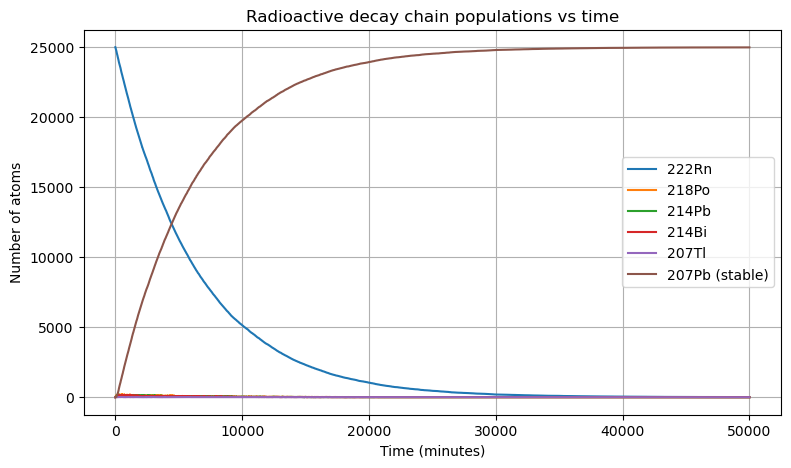

=== Part 2: Single run decay counts and energies ===
Decay type a:
  Number of decays: 27734
  Total energy: 138670.00 MeV
Decay type b:
  Number of decays: 24988
  Total energy: 12494.00 MeV
Decay type R:
  Number of decays: 25476
  Total energy: 50952.00 MeV
Decay type Z:
  Number of decays: 24502
  Total energy: 294024.00 MeV

Total energy from all decays: 496140.00 MeV


In [36]:
# Run one simulation
(time_array, Rn_array, Po_array, Pb_array, Bi_array, Tl_array,
 Pb207_array, energy1, counts1, total_E1) = simulate_one_run()

#plot for population vs time
plt.figure(figsize=(9, 5))
plt.plot(time_array, Rn_array,    label="222Rn")
plt.plot(time_array, Po_array,    label="218Po")
plt.plot(time_array, Pb_array,    label="214Pb")
plt.plot(time_array, Bi_array,    label="214Bi")
plt.plot(time_array, Tl_array,    label="207Tl")
plt.plot(time_array, Pb207_array, label="207Pb (stable)")

plt.xlabel("Time (minutes)")
plt.ylabel("Number of atoms")
plt.title("Radioactive decay chain populations vs time")
plt.legend()
plt.grid(True)
plt.show()

#num of decays and energy
print("=== Part 2: Single run decay counts and energies ===")
for k in ["a", "b", "R", "Z"]:
    print(f"Decay type {k}:")
    print(f"  Number of decays: {counts1[k]}")
    print(f"  Total energy: {energy1[k]:.2f} MeV")
print(f"\nTotal energy from all decays: {total_E1:.2f} MeV")


In [37]:
types = ["a", "b", "R", "Z"]
n_runs = 10

energies = np.zeros((n_runs, len(types) + 1))

for r in range(n_runs):
    (_, _, _, _, _, _, _,
     e_by_type, _, e_total) = simulate_one_run()
    for j, k in enumerate(types):
        energies[r, j] = e_by_type[k]
    energies[r, -1] = e_total

# average and standard deviation (sample std: ddof=1)
means = energies.mean(axis=0)
stds  = energies.std(axis=0, ddof=1)

print("=== Part 3: Mean and standard deviation of energies (MeV) ===")
for j, k in enumerate(types):
    print(f"Type {k}: mean = {means[j]:.2f} MeV,  std = {stds[j]:.2f} MeV")
print(f"Total: mean = {means[-1]:.2f} MeV,  std = {stds[-1]:.2f} MeV")

=== Part 3: Mean and standard deviation of energies (MeV) ===
Type a: mean = 138663.50 MeV,  std = 271.51 MeV
Type b: mean = 12495.25 MeV,  std = 1.67 MeV
Type R: mean = 50985.60 MeV,  std = 50.97 MeV
Type Z: mean = 293858.40 MeV,  std = 252.46 MeV
Total: mean = 496002.75 MeV,  std = 321.51 MeV


In [38]:
material_info = {
    "a": {"name": "Wood", "block": 1000.0, "cost_per_cm": 0.15},
    "b": {"name": "Water", "block": 8000.0, "cost_per_cm": 1.50},
    "R": {"name": "Gold", "block": 8000.0, "cost_per_cm": 150.0},
    "Z": {"name": "Lead", "block": 1000.0, "cost_per_cm": 15.0},
}

print("=== Part 4: Shield thickness and cost (blocking mean + 3σ) ===")
for j, k in enumerate(types):
    mean_E = means[j]
    std_E  = stds[j]

    E_block = mean_E +3.0 * std_E

    info = material_info[k]
    thickness_cm = E_block / info["block"]
    cost = thickness_cm * info["cost_per_cm"]

    print(f"Decay type {k} ({info['name']}):")
    print(f"  Energy to block: {E_block:.2f} MeV")
    print(f"  Required thickness: {thickness_cm:.3f} cm")
    print(f"  Cost: ${cost:.2f}\n")

=== Part 4: Shield thickness and cost (blocking mean + 3σ) ===
Decay type a (Wood):
  Energy to block: 139478.03 MeV
  Required thickness: 139.478 cm
  Cost: $20.92

Decay type b (Water):
  Energy to block: 12500.26 MeV
  Required thickness: 1.563 cm
  Cost: $2.34

Decay type R (Gold):
  Energy to block: 51138.51 MeV
  Required thickness: 6.392 cm
  Cost: $958.85

Decay type Z (Lead):
  Energy to block: 294615.79 MeV
  Required thickness: 294.616 cm
  Cost: $4419.24

